# Evaluate model-based bakery under-provision

This notebook compares the final modelled under-provision results.

Three approaches are compared:
1. simple population and area-density baselines
2. the population and transport Negative Binomial model
3. the income-extended Negative Binomial model

The population-and-transport model is compared with the income-extended model to assess whether the improvement in model fit substantially changes the MSOA rankings of relative under-provision.

In [1]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DATE = "2026-07-23"
EXPECTED_MSOAS = 1002

MODEL_OUTPUT_FOLDER = Path("../outputs/models")
TABLE_FOLDER = Path("../outputs/tables")
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

FINAL_RESULTS_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_underprovision_{DATA_DATE}.csv")
BASE_MODEL_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_model_predictions_{DATA_DATE}.csv")
BASE_MODEL_COMPARISON_PATH = (TABLE_FOLDER / f"bakery_count_model_comparison_{DATA_DATE}.csv")

## Load the modelling results

The final income-model results from Notebook 18 are combined with the original Negative Binomial predictions from Notebook 17 to compare them against the same MSOAs.

In [2]:
final_results = pd.read_csv(FINAL_RESULTS_PATH, dtype={"msoa_code": "string"}, low_memory=False)
base_predictions = pd.read_csv(BASE_MODEL_PATH, dtype={"msoa_code": "string"}, low_memory=False)

base_model_comparison = pd.read_csv(BASE_MODEL_COMPARISON_PATH)

base_expected_columns = ["expected_core_bakery_count",
                         "expected_core_and_cafe_count",
                         "expected_bakery_count"]

evaluation_data = final_results.merge(base_predictions[["msoa_code"] + base_expected_columns],
                                      on="msoa_code",
                                      how="left",
                                      validate="one_to_one")

definition_settings = {"Core only": {"prefix": "core",
                                     "observed": "core_bakery_count",
                                     "base_expected": "expected_core_bakery_count",
                                     "income_score": "core_standardised_shortfall",
                                     "income_percentile": "core_underprovision_percentile"},
                       "Core and café": {"prefix": "core_cafe",
                                         "observed": "core_and_cafe_count",
                                         "base_expected": "expected_core_and_cafe_count",
                                         "income_score": "core_cafe_standardised_shortfall",
                                         "income_percentile": "core_cafe_underprovision_percentile"},
                       "All provision included": {"prefix": "all",
                                                  "observed": "bakery_count",
                                                  "base_expected": "expected_bakery_count",
                                                  "income_score": "all_standardised_shortfall",
                                                  "income_percentile": "all_underprovision_percentile"}}

required_columns = ["msoa_code",
                    "msoa_name",
                    "borough_name",
                    "area_km2",
                    "population",
                    "core_bakery_count",
                    "core_and_cafe_count",
                    "bakery_count",
                    "core_standardised_shortfall",
                    "core_cafe_standardised_shortfall",
                    "all_standardised_shortfall"] + base_expected_columns

missing_columns = [column for column in required_columns
                   if column not in evaluation_data.columns]

if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

if len(evaluation_data) != EXPECTED_MSOAS:
    raise RuntimeError(f"Expected {EXPECTED_MSOAS} MSOAs, but found {len(evaluation_data)}.")

if evaluation_data["msoa_code"].duplicated().any():
    raise RuntimeError("Duplicate MSOA codes found.")

if evaluation_data[required_columns].isna().any().any():
    raise RuntimeError("Missing required values found.")

print(f"Final result rows: {len(final_results)}")
print(f"Rows available for evaluation: {len(evaluation_data)}")
print(f"Duplicate MSOA codes: {evaluation_data['msoa_code'].duplicated().sum()}")
print(f"Missing required values: {evaluation_data[required_columns].isna().sum().sum()}")

Final result rows: 1002
Rows available for evaluation: 1002
Duplicate MSOA codes: 0
Missing required values: 0


## Creating baseline and base-model score

A population baseline estimates expected establishments based on the London rate per resident, while an area baseline uses establishment density per kilometre for London.

In [3]:
total_population = evaluation_data["population"].sum()
total_area = evaluation_data["area_km2"].sum()

base_alpha_lookup = (base_model_comparison
                     .set_index("Definition")["Negative Binomial alpha"]
                     .to_dict())

baseline_summary_rows = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]
    observed = evaluation_data[settings["observed"]]
    base_expected = evaluation_data[settings["base_expected"]]

    # Population and transport model from Notebook 17
    base_alpha = base_alpha_lookup[definition]

    base_variance = (base_expected + base_alpha * base_expected ** 2)

    evaluation_data[f"{prefix}_base_model_score"
                    ] = ((base_expected - observed) / np.sqrt(base_variance))

    evaluation_data[f"{prefix}_base_model_percentile"
                    ] = (evaluation_data[f"{prefix}_base_model_score"]
                         .rank(method="average", pct=True) * 100)

    # Population baseline
    london_rate_per_person = (observed.sum() / total_population)

    evaluation_data[f"{prefix}_population_baseline_expected"
                    ] = (evaluation_data["population"] * london_rate_per_person)

    evaluation_data[f"{prefix}_population_baseline_shortfall"
                    ] = (evaluation_data[f"{prefix}_population_baseline_expected"] - observed)

    evaluation_data[f"{prefix}_population_baseline_percentile"
                    ] = (evaluation_data[f"{prefix}_population_baseline_shortfall"]
                         .rank(method="average", pct=True) * 100)

    # Area-density baseline
    london_rate_per_km2 = (observed.sum() / total_area)

    evaluation_data[f"{prefix}_density_baseline_expected"
                    ] = (evaluation_data["area_km2"] * london_rate_per_km2)

    evaluation_data[f"{prefix}_density_baseline_shortfall"
                    ] = (evaluation_data[f"{prefix}_density_baseline_expected"] - observed)

    evaluation_data[f"{prefix}_density_baseline_percentile"
                    ] = (evaluation_data[f"{prefix}_density_baseline_shortfall"]
                         .rank(method="average", pct=True) * 100)

    baseline_summary_rows.append({"Definition": definition,
                                 "Observed establishments": observed.sum(),
                                 "London rate per 10,000 residents": (london_rate_per_person * 10000),
                                 "London establishments per km²": london_rate_per_km2,
                                 "Population expected total": (evaluation_data[f"{prefix}_population_baseline_expected"
                                                                               ].sum()),
                                 "Density expected total": (evaluation_data[f"{prefix}_density_baseline_expected"
                                                                            ].sum())})

baseline_summary = pd.DataFrame(baseline_summary_rows)

display(
    baseline_summary.round({"London rate per 10,000 residents": 2,
                            "London establishments per km²": 2,
                            "Population expected total": 1,
                            "Density expected total": 1}))

,Definition,Observed establishments,"London rate per 10,000 residents",London establishments per km²,Population expected total,Density expected total
0,Core only,925,1.02,0.58,925.0,925.0
1,Core and café,2928,3.22,1.84,2928.0,2928.0
2,All provision included,5178,5.70,3.25,5178.0,5178.0


## Compare both models with the baselines

Rank correlation measures whether two methods order the MSOAs similarly while top-decile overlap shows how much of the top 10% MSOAs are similar in both cases of relative-underprovision.

In [4]:
comparison_rows = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]

    model_percentiles = {"Population and transport model": (f"{prefix}_base_model_percentile"),
                         "Income-extended model": (settings["income_percentile"])}

    baseline_percentiles = {"Population baseline": (f"{prefix}_population_baseline_percentile"),
                            "Area-density baseline": (f"{prefix}_density_baseline_percentile")}

    for model_name, model_column in model_percentiles.items():
        model_top = (evaluation_data[model_column] >= 90)

        for baseline_name, baseline_column in baseline_percentiles.items():
            baseline_top = (evaluation_data[baseline_column] >= 90)

            shared_top = (model_top & baseline_top).sum()

            comparison_rows.append({"Definition": definition,
                                    "Model": model_name,
                                    "Baseline": baseline_name,
                                    "Rank correlation": (evaluation_data[model_column]
                                                         .corr(evaluation_data[baseline_column],
                                                               method="spearman")),
                                    "Model top-decile MSOAs": model_top.sum(),
                                    "Baseline top-decile MSOAs": baseline_top.sum(),
                                    "Shared top-decile MSOAs": shared_top,
                                    "Top-decile overlap (%)": (shared_top / model_top.sum() * 100)})

model_baseline_comparison = pd.DataFrame(comparison_rows)

display(model_baseline_comparison.round({"Rank correlation": 3,
                                         "Top-decile overlap (%)": 1}))

,Definition,Model,Baseline,Rank correlation,Model top-decile MSOAs,Baseline top-decile MSOAs,Shared top-decile MSOAs,Top-decile overlap (%)
0,Core only,Population and transport model,Population baseline,0.841,101,101,35,34.7
1,Core only,Population and transport model,Area-density baseline,0.868,101,101,49,48.5
2,Core only,Income-extended model,Population baseline,0.835,101,101,33,32.7
3,Core only,Income-extended model,Area-density baseline,0.849,101,101,45,44.6
4,Core and café,Population and transport model,Population baseline,0.886,101,100,34,33.7
5,Core and café,Population and transport model,Area-density baseline,0.853,101,101,39,38.6
6,Core and café,Income-extended model,Population baseline,0.849,101,100,32,31.7
7,Core and café,Income-extended model,Area-density baseline,0.814,101,101,35,34.7
8,All provision included,Population and transport model,Population baseline,0.910,101,101,50,49.5
9,All provision included,Population and transport model,Area-density baseline,0.864,101,101,28,27.7


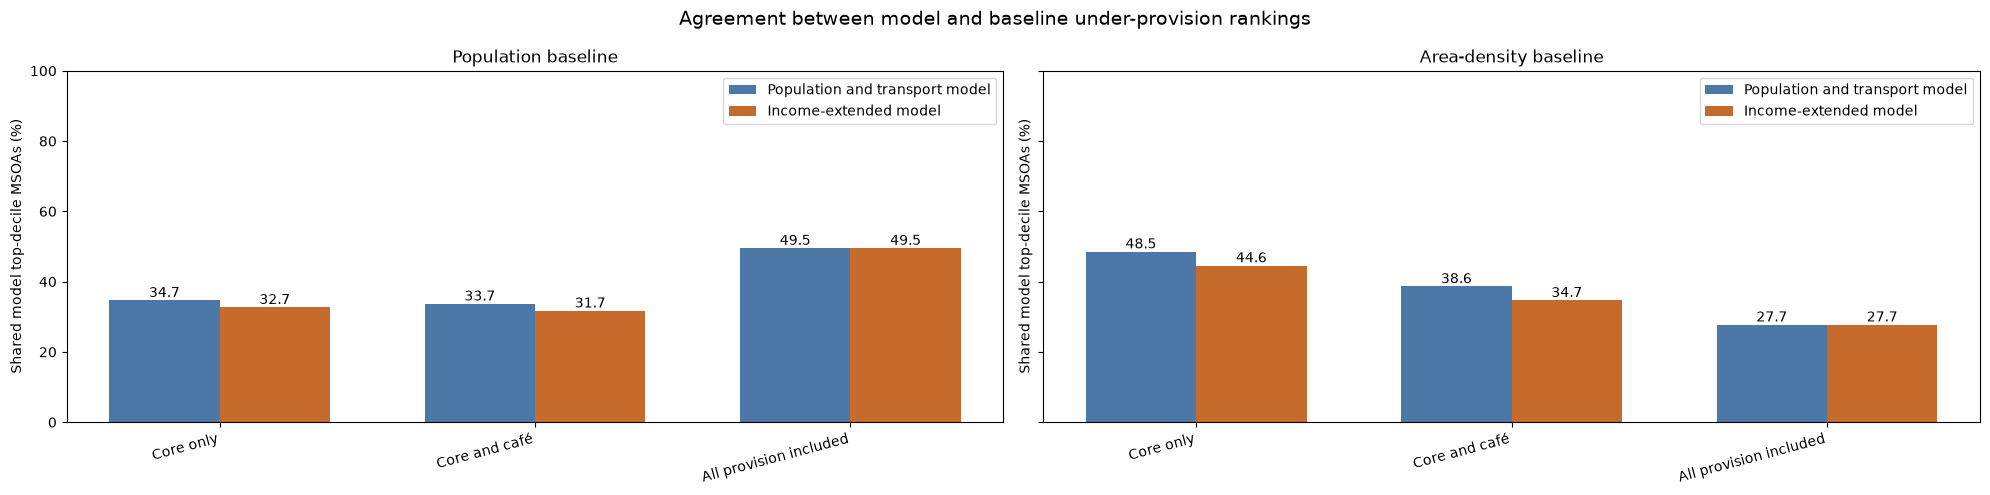

Saved to: ..\outputs\figures\model_baseline_top_decile_overlap_2026-07-23.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

baseline_names = ["Population baseline", "Area-density baseline"]

model_names = ["Population and transport model", "Income-extended model"]

model_colours = ["#4c78a8", "#c66b2b"]

definitions = list(definition_settings.keys())
x_positions = np.arange(len(definitions))
bar_width = 0.35

for axis, baseline_name in zip(axes, baseline_names):
    for position, (model_name, colour) in enumerate(zip(model_names, model_colours)):
        values = []

        for definition in definitions:
            result = model_baseline_comparison[(model_baseline_comparison["Definition"] == definition)
                                               & (model_baseline_comparison["Model"] == model_name)
                                               & (model_baseline_comparison["Baseline"] == baseline_name)]

            values.append(result["Top-decile overlap (%)"].iloc[0])

        offset = (-bar_width / 2
                  if position == 0
                  else bar_width / 2)

        bars = axis.bar(x_positions + offset,
                        values,
                        width=bar_width,
                        label=model_name,
                        color=colour)

        axis.bar_label(bars, fmt="%.1f")

    axis.set_title(baseline_name)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(definitions, rotation=15, ha="right")

    axis.set_ylim(0, 100)
    axis.set_ylabel("Shared model top-decile MSOAs (%)")
    axis.legend()

fig.suptitle("Agreement between model and baseline under-provision rankings", fontsize=14)

plt.tight_layout()
BASELINE_FIGURE_PATH = (FIGURE_FOLDER / f"model_baseline_top_decile_overlap_{DATA_DATE}.png")
plt.savefig(BASELINE_FIGURE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {BASELINE_FIGURE_PATH}")

## Top-decile comparison

In [6]:
definitions = {"Core only": ("core_bakery_count", "core_standardised_shortfall",
                             "core_underprovision_rank", "core_top_decile"),
               "Core and café": ("core_and_cafe_count", "core_cafe_standardised_shortfall",
                                 "core_cafe_underprovision_rank", "core_cafe_top_decile"),
               "All provision": ("bakery_count", "all_standardised_shortfall",
                                 "all_underprovision_rank", "all_top_decile")}

rows = []

for name, (count_col, score_col, rank_col, top_col) in definitions.items():

    top = evaluation_data[evaluation_data[top_col]
                          ].sort_values(rank_col)

    zero = top[top[count_col] == 0]
    nonzero = top[top[count_col] > 0]

    rows.append({"Definition": name,
                 "Top decile": len(top),
                 "Zero count": len(zero),
                 "Zero %": round(len(zero) / len(top) * 100, 1),
                 "Last zero rank": zero[rank_col].max(),
                 "First non-zero rank": nonzero[rank_col].min(),
                 "Zero score min": round(zero[score_col].min(), 3),
                 "Zero score max": round(zero[score_col].max(), 3)})

pd.DataFrame(rows)

,Definition,Top decile,Zero count,Zero %,Last zero rank,First non-zero rank,Zero score min,Zero score max
0,Core only,101,101,100.0,101,NaN,0.708,0.814
1,Core and café,101,101,100.0,101,NaN,0.813,0.903
2,All provision,101,94,93.1,101,50.0,0.979,1.142


## Assess the effect of adding income

The population and transport model is directly compared with the income-extended model to see if the model fit better without leading to much geographical change. This will be seen through high correlation and top-decile overlap.

In [8]:
model_stability_rows = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]

    base_score = evaluation_data[f"{prefix}_base_model_score"]
    income_score = evaluation_data[settings["income_score"]]
    base_percentile = evaluation_data[f"{prefix}_base_model_percentile"]
    income_percentile = evaluation_data[settings["income_percentile"]]

    base_top = (base_percentile >= 90)
    income_top = (income_percentile >= 90)
    shared_top = (base_top & income_top).sum()

    model_stability_rows.append({"Definition": definition,
                                 "Base and income rank correlation": (base_score
                                                                      .corr(income_score, method="spearman")),
                                 "Base-model top-decile MSOAs": base_top.sum(),
                                 "Income-model top-decile MSOAs": income_top.sum(),
                                 "Shared top-decile MSOAs": shared_top,
                                 "Top-decile overlap (%)": (shared_top / income_top.sum() * 100),
                                 "Mean percentile change": (base_percentile - income_percentile).abs().mean()})

base_income_stability = pd.DataFrame(model_stability_rows)

display(base_income_stability.round({"Base and income rank correlation": 3,
                                     "Top-decile overlap (%)": 2,
                                     "Mean percentile change": 2}))

,Definition,Base and income rank correlation,Base-model top-decile MSOAs,Income-model top-decile MSOAs,Shared top-decile MSOAs,Top-decile overlap (%),Mean percentile change
0,Core only,0.984,101,101,78,77.23,3.55
1,Core and café,0.961,101,101,69,68.32,5.82
2,All provision included,0.969,101,101,92,91.09,5.07


## Compare the final top-ranked MSOAs across methods

Rankings are compared across:
- the final income-extended model
- the population and transport model
- the population-only baseline
- the area-density baseline

Core bakeries and bakery cafés are used as the primary definition as this definition produced the highest inclusion agreement while retaining greater coverage than the core-only definition.

The 20 highest-ranked MSOAs from the final income model are shown alongside their ranks under the three alternative approaches.

In [9]:
evaluation_data["core_cafe_base_model_rank"] = (evaluation_data["core_cafe_base_model_score"]
                                                .rank(method="min", ascending=False)
                                                .astype(int))

evaluation_data["core_cafe_population_baseline_rank"] = (evaluation_data["core_cafe_population_baseline_shortfall"]
                                                         .rank(method="min", ascending=False)
                                                         .astype(int))

evaluation_data["core_cafe_density_baseline_rank"] = (evaluation_data["core_cafe_density_baseline_shortfall"]
                                                      .rank(method="min", ascending=False)
                                                      .astype(int))

primary_rank_comparison = (evaluation_data
                           .sort_values("core_cafe_underprovision_rank")
                           .head(20)[["msoa_code",
                                      "msoa_name",
                                      "borough_name",
                                      "core_cafe_underprovision_rank",
                                      "core_cafe_base_model_rank",
                                      "core_cafe_population_baseline_rank",
                                      "core_cafe_density_baseline_rank",
                                      "core_underprovision_rank",
                                      "all_underprovision_rank"]].copy())

primary_rank_comparison = primary_rank_comparison.rename(
    columns={"core_cafe_underprovision_rank": "Income based core and café rank",
             "core_cafe_base_model_rank": "Population and transport model rank",
             "core_cafe_population_baseline_rank": "Population baseline rank",
             "core_cafe_density_baseline_rank": "Area-density baseline rank",
             "core_underprovision_rank": "Core-only rank",
             "all_underprovision_rank": "All-provision rank"})

display(primary_rank_comparison)

,msoa_code,msoa_name,borough_name,Income based core and café rank,Population and transport model rank,Population baseline rank,Area-density baseline rank,Core-only rank,All-provision rank
222,E02000234,Croydon 041,Croydon,1,2,72,61,5,110
939,E02006789,Bromley 042,Bromley,2,1,340,1,2,71
140,E02000147,Bromley 021,Bromley,3,9,194,94,13,2
766,E02000814,Southwark 008,Southwark,4,56,41,272,39,1
215,E02000227,Croydon 034,Croydon,5,4,15,35,9,50
28,E02000030,Barnet 007,Barnet,6,6,101,5,10,78
224,E02000236,Croydon 043,Croydon,7,8,104,48,25,168
752,E02000798,Richmond upon Thames 015,Richmond upon Thames,8,20,23,85,35,148
219,E02000231,Croydon 038,Croydon,9,10,182,52,28,3
208,E02000219,Croydon 026,Croydon,10,7,239,22,17,99


## Save evaluation outputs

In [10]:
EVALUATION_DATA_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_model_evaluation_{DATA_DATE}.csv")
BASELINE_SUMMARY_PATH = (TABLE_FOLDER / f"bakery_baseline_summary_{DATA_DATE}.csv")
MODEL_BASELINE_PATH = (TABLE_FOLDER / f"model_baseline_comparison_{DATA_DATE}.csv")
MODEL_STABILITY_PATH = (TABLE_FOLDER / f"base_income_ranking_stability_{DATA_DATE}.csv")
PRIMARY_RANK_COMPARISON_PATH = (TABLE_FOLDER / f"core_cafe_top_20_rank_comparison_{DATA_DATE}.csv")

evaluation_data.to_csv(EVALUATION_DATA_PATH, index=False, encoding="utf-8-sig")
baseline_summary.to_csv(BASELINE_SUMMARY_PATH, index=False, encoding="utf-8-sig")
model_baseline_comparison.to_csv(MODEL_BASELINE_PATH, index=False, encoding="utf-8-sig")
base_income_stability.to_csv(MODEL_STABILITY_PATH, index=False, encoding="utf-8-sig")
primary_rank_comparison.to_csv(PRIMARY_RANK_COMPARISON_PATH, index=False, encoding="utf-8-sig")

print(f"Complete evaluation saved to: {EVALUATION_DATA_PATH}")
print(f"Baseline summary saved to: {BASELINE_SUMMARY_PATH}")
print(f"Model-baseline comparison saved to: {MODEL_BASELINE_PATH}")
print(f"Model stability saved to: {MODEL_STABILITY_PATH}")
print(f"Primary rank comparison saved to: {PRIMARY_RANK_COMPARISON_PATH}")

Complete evaluation saved to: ..\outputs\models\london_msoa_bakery_model_evaluation_2026-07-23.csv
Baseline summary saved to: ..\outputs\tables\bakery_baseline_summary_2026-07-23.csv
Model-baseline comparison saved to: ..\outputs\tables\model_baseline_comparison_2026-07-23.csv
Model stability saved to: ..\outputs\tables\base_income_ranking_stability_2026-07-23.csv
Primary rank comparison saved to: ..\outputs\tables\core_cafe_top_20_rank_comparison_2026-07-23.csv
